# Imports + config

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from statsmodels.tsa.seasonal import STL

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ---- Config ----
TZ_MODEL = "UTC"
TZ_LOCAL = "Europe/Paris"
TZ = TZ_MODEL  # kept for compatibility (not used with OPSD)

SEQ_LEN = 24*14      # 14 jours d'historique
HORIZON = 24         # 24h ahead
PATCH_LEN = 4        # patching (4h par token)
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 3
DROPOUT = 0.1

BATCH = 64
EPOCHS = 2
LR = 3e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NEIGHBORS = ["BE", "DE_LU", "ES", "CH", "IT", "GB"]  # voisins utiles pour flows 

# Download data (no API key): OPSD time series (ENTSO-E mirrored)


In [31]:
import pandas as pd

# OPSD time series (hourly) – version 2020-10-06 (latest sur leur page)
url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"

df_raw = pd.read_csv(url)

# timestamp (le fichier contient utc_timestamp + cet_cest_timestamp)
df_raw["utc_timestamp"] = pd.to_datetime(df_raw["utc_timestamp"], utc=True)
df_raw = df_raw.set_index("utc_timestamp").sort_index()

# colonne load France (issue ENTSO-E)
df = pd.DataFrame({
    "load_mw": df_raw["FR_load_actual_entsoe_transparency"]
})

# optionnel : si dispo, tu peux aussi prendre du wind/solar FR (noms exacts peuvent varier)
for col in df_raw.columns:
    c = col.lower()
    if col.startswith("FR_") and ("wind" in c or "solar" in c):
        df[col] = df_raw[col]

df = df.dropna(subset=["load_mw"]).resample("H").mean()
df.head()

C:\Users\karim\AppData\Local\Temp\ipykernel_32268\2342736686.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.dropna(subset=["load_mw"]).resample("H").mean()


,load_mw,FR_solar_generation_actual,FR_wind_onshore_generation_actual
utc_timestamp,,,
2015-01-01 01:00:00+00:00,69773.0,NaN,1464.0
2015-01-01 02:00:00+00:00,66417.0,NaN,1543.0
2015-01-01 03:00:00+00:00,64182.0,NaN,1579.0
2015-01-01 04:00:00+00:00,63859.0,NaN,1482.0
2015-01-01 05:00:00+00:00,63921.0,NaN,1387.0


# 3) Cleaning + features calendrier + renewable_share + ramping

In [32]:
# Use df loaded from OPSD (cell above). Build features without ENTSO-E API objects.

# Ensure hourly regularity
df = df.sort_index()
df = df[~df.index.duplicated(keep="first")]
df = df.asfreq("H")  # keep a regular hourly grid

# Fill small gaps in load
df["load_mw"] = df["load_mw"].interpolate(limit=6)

# --- Renewable proxy (wind+solar / load) if wind/solar columns exist in OPSD ---
wind_cols  = [c for c in df.columns if "wind" in c.lower()]
solar_cols = [c for c in df.columns if "solar" in c.lower()]

df["wind_solar_mw"] = 0.0
if wind_cols:
    df["wind_solar_mw"] += df[wind_cols].sum(axis=1)
if solar_cols:
    df["wind_solar_mw"] += df[solar_cols].sum(axis=1)

# NOTE: Without total generation & flows, this is a proxy of "renewables pressure"
df["renewable_share"] = (df["wind_solar_mw"] / df["load_mw"]).replace([np.inf, -np.inf], np.nan).clip(0, 1)
df["renewable_share"] = df["renewable_share"].fillna(0.0)

# --- Net import not available without ENTSO-E API ---
df["net_import_mw"] = 0.0

# --- Ramping proxy ---
df["ramping_abs"] = df["load_mw"].diff().abs().fillna(0.0)

# --- Calendar features (use Paris local clock for hour/dow) ---
local_time = df.index.tz_convert(TZ_LOCAL) if getattr(df.index, "tz", None) is not None else df.index
df["hour"] = local_time.hour
df["dow"] = local_time.dayofweek
df["month"] = local_time.month
df["is_weekend"] = (df["dow"] >= 5).astype(int)

df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
df["dow_sin"]  = np.sin(2*np.pi*df["dow"]/7)
df["dow_cos"]  = np.cos(2*np.pi*df["dow"]/7)
df["mon_sin"]  = np.sin(2*np.pi*df["month"]/12)
df["mon_cos"]  = np.cos(2*np.pi*df["month"]/12)

# holidays (France)
try:
    import holidays
    fr_h = holidays.France()
    df["is_holiday"] = [int(ts.date() in fr_h) for ts in local_time]
except Exception:
    df["is_holiday"] = 0

df = df.dropna(subset=["load_mw"])
df.head()


C:\Users\karim\AppData\Local\Temp\ipykernel_32268\3565368279.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq("H")  # keep a regular hourly grid


,load_mw,FR_solar_generation_actual,FR_wind_onshore_generation_actual,wind_solar_mw,renewable_share,net_import_mw,ramping_abs,hour,dow,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,mon_sin,mon_cos,is_holiday
utc_timestamp,,,,,,,,,,,,,,,,,,
2015-01-01 01:00:00+00:00,69773.0,NaN,1464.0,1464.0,0.020982,0.0,0.0,2,3,1,0,0.500000,8.660254e-01,0.433884,-0.900969,0.5,0.866025,1
2015-01-01 02:00:00+00:00,66417.0,NaN,1543.0,1543.0,0.023232,0.0,3356.0,3,3,1,0,0.707107,7.071068e-01,0.433884,-0.900969,0.5,0.866025,1
2015-01-01 03:00:00+00:00,64182.0,NaN,1579.0,1579.0,0.024602,0.0,2235.0,4,3,1,0,0.866025,5.000000e-01,0.433884,-0.900969,0.5,0.866025,1
2015-01-01 04:00:00+00:00,63859.0,NaN,1482.0,1482.0,0.023207,0.0,323.0,5,3,1,0,0.965926,2.588190e-01,0.433884,-0.900969,0.5,0.866025,1
2015-01-01 05:00:00+00:00,63921.0,NaN,1387.0,1387.0,0.021699,0.0,62.0,6,3,1,0,1.000000,6.123234e-17,0.433884,-0.900969,0.5,0.866025,1


# 4) Figure 1 — Série + split

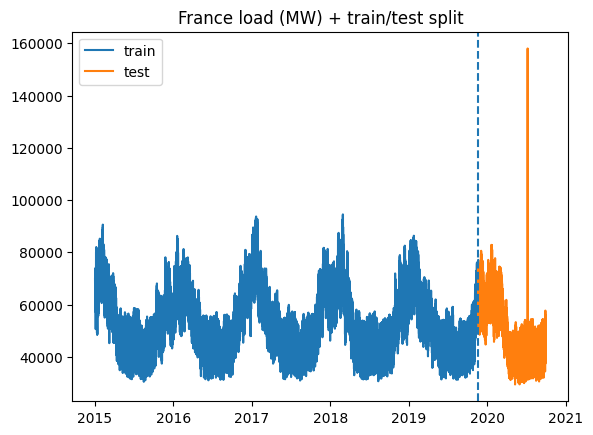

In [33]:
# Train/test split temporel
split_date = df.index[int(len(df)*0.85)]
train_df = df[df.index < split_date].copy()
test_df  = df[df.index >= split_date].copy()

plt.figure()
plt.plot(train_df.index, train_df["load_mw"], label="train")
plt.plot(test_df.index,  test_df["load_mw"], label="test")
plt.axvline(split_date, linestyle="--")
plt.title("France load (MW) + train/test split")
plt.legend()
plt.show()

# 5) Baseline naïf (t-24) — Figure 2 (baseline vs transformer ensuite)

In [34]:
def naive_pred_tminus24(series):
    return series.shift(24)

test_naive = naive_pred_tminus24(df["load_mw"]).loc[test_df.index]
baseline_mae = (test_df["load_mw"] - test_naive).abs().mean()
print("Baseline MAE (t-24):", baseline_mae)

Baseline MAE (t-24): 2793.735723429025


# 6) STL decomposition — Figure 4

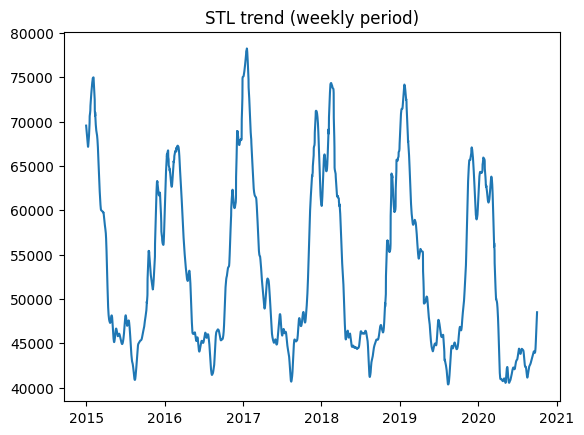

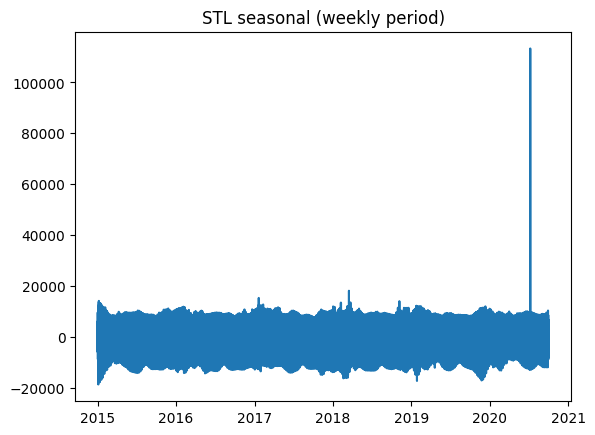

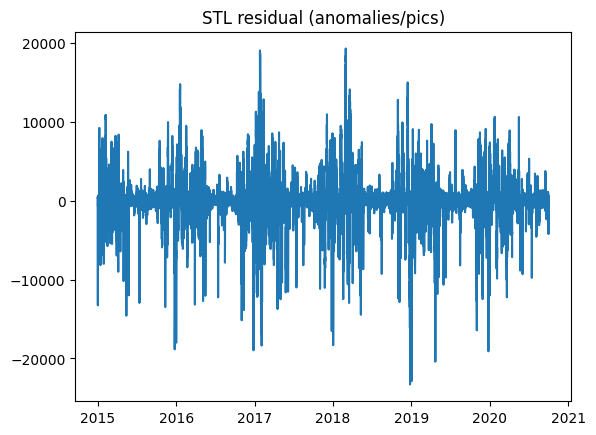

In [37]:
stl_week = STL(df["load_mw"], period=24*7, robust=True).fit()

plt.figure()
plt.plot(stl_week.trend)
plt.title("STL trend (weekly period)")
plt.show()

plt.figure()
plt.plot(stl_week.seasonal)
plt.title("STL seasonal (weekly period)")
plt.show()

plt.figure()
plt.plot(stl_week.resid)
plt.title("STL residual (anomalies/pics)")
plt.show()

# 7) Dataset windows + scaling

In [ ]:
FEATURES = [
    "load_mw",
    "hour_sin","hour_cos","dow_sin","dow_cos","mon_sin","mon_cos",
    "is_weekend","is_holiday",
    "renewable_share","net_import_mw","ramping_abs"
]

# fill remaining NaNs for net_import etc.
df_model = df.copy()
df_model["net_import_mw"] = df_model["net_import_mw"].fillna(0.0)
df_model["ramping_abs"]   = df_model["ramping_abs"].fillna(df_model["ramping_abs"].median())

# scale load target + load feature (important)
scaler_y = StandardScaler()
scaler_y.fit(train_df[["load_mw"]])

df_model["load_scaled"] = scaler_y.transform(df_model[["load_mw"]])

# replace "load_mw" feature with scaled version in model features
FEATURES_MODEL = FEATURES.copy()
FEATURES_MODEL[FEATURES_MODEL.index("load_mw")] = "load_scaled"


class WindowDS(Dataset):
    """Dataset corrigé: prédit UNIQUEMENT t+24h"""
    def __init__(self, df, features, seq_len, horizon=24):
        self.X = df[features].values.astype(np.float32)
        self.y = df["load_scaled"].values.astype(np.float32)
        self.seq_len = seq_len
        self.horizon = horizon
        self.starts = list(range(seq_len, len(df) - horizon))
    
    def __len__(self):
        return len(self.starts)
    
    def __getitem__(self, k):
        i = self.starts[k]
        x = self.X[i-self.seq_len:i]
        y_target = self.y[i + self.horizon - 1]  # Doit être un float, pas array
        return torch.from_numpy(x), torch.tensor(y_target, dtype=torch.float32)

class WindowDSPlot(WindowDS):
    def __init__(self, df, features, seq_len, horizon, index):
        super().__init__(df, features, seq_len, horizon)
        self.index = index  # df.index

    def __getitem__(self, k):
        i = self.starts[k]
        x = self.X[i-self.seq_len:i]
        y = self.y[i:i+self.h]
        return torch.from_numpy(x), torch.from_numpy(y), i

train_ds = WindowDS(
    df_model.loc[train_df.index], 
    FEATURES_MODEL, 
    SEQ_LEN, 
    HORIZON
)
test_ds = WindowDS(
    df_model.loc[test_df.index], 
    FEATURES_MODEL, 
    SEQ_LEN, 
    HORIZON
)

train_loader_fixed = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True)
test_loader_fixed = DataLoader(test_ds, batch_size=BATCH, shuffle=False, drop_last=False)

print(f" Datasets créés:")
print(f"   Train: {len(train_ds)} samples")
print(f"   Test:  {len(test_ds)} samples")

# Vérifier la shape des outputs
xb, yb = next(iter(train_loader_fixed))
print(f"\n Shapes:")
print(f"   X: {xb.shape} (batch, seq_len, features)")
print(f"   Y: {yb.shape} (batch,) <- SCALAIRE! ")

✅ Datasets créés:
   Train: 42472 samples
   Test:  7199 samples

✅ Shapes:
   X: torch.Size([64, 336, 12]) (batch, seq_len, features)
   Y: torch.Size([64]) (batch,) <- SCALAIRE! ✅


# 8) Patch Transformer + attention weights (Attention maps)

In [ ]:
class EncoderLayerWithAttn(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1, d_ff=4):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff*d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff*d_model, d_model),
            nn.Dropout(dropout),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.last_attn = None  # (B, heads, S, S)

    def forward(self, x):
        # need_weights=True, average_attn_weights=False -> get per-head weights
        out, attn = self.mha(x, x, x, need_weights=True, average_attn_weights=False)
        self.last_attn = attn
        x = self.norm1(x + out)
        x = self.norm2(x + self.ff(x))
        return x
    

class PatchTransformer(nn.Module):
    def __init__(self, seq_len, n_features, patch_len=4, d_model=128, 
                 n_heads=4, n_layers=3, dropout=0.1):
        super().__init__()
        assert seq_len % patch_len == 0
        self.seq_len = seq_len
        self.patch_len = patch_len
        self.n_patches = seq_len // patch_len
        
        self.patch_proj = nn.Linear(patch_len * n_features, d_model)
        self.pos = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
        
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=n_heads,
                dim_feedforward=4*d_model,
                dropout=dropout,
                batch_first=True
            ) for _ in range(n_layers)
        ])
        
        # ✅ CORRECTION: Head qui prédit 1 seule valeur
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )
    
    def forward(self, x):
        B, S, F = x.shape
        x = x.view(B, self.n_patches, self.patch_len * F)
        x = self.patch_proj(x) + self.pos
        
        for layer in self.layers:
            x = layer(x)
        
        # ✅ CORRECTION: Utiliser le dernier patch au lieu de mean
        last_patch = x[:, -1, :]  # (B, d_model)
        
        yhat = self.head(last_patch).squeeze(-1)  # (B,)
        return yhat

    def get_last_attention(self):
        # return attention of last layer (B, heads, P, P)
        return self.layers[-1].last_attn

model_fixed = PatchTransformer(
    seq_len=SEQ_LEN,
    n_features=len(FEATURES_MODEL),
    patch_len=PATCH_LEN,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)



class PatchTransformer(nn.Module):
    """Transformer corrigé: pas de mean pooling, prédit 1 valeur"""
    def __init__(self, seq_len, n_features, patch_len=4, d_model=128, 
                 n_heads=4, n_layers=3, dropout=0.1):
        super().__init__()
        assert seq_len % patch_len == 0
        self.seq_len = seq_len
        self.patch_len = patch_len
        self.n_patches = seq_len // patch_len
        
        self.patch_proj = nn.Linear(patch_len * n_features, d_model)
        self.pos = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
        
        # EncoderLayerWithAttn au lieu de nn.TransformerEncoderLayer
        self.layers = nn.ModuleList([
            EncoderLayerWithAttn(
                d_model=d_model,
                n_heads=n_heads,
                dropout=dropout,
                d_ff=4  # dim_feedforward = 4*d_model
            ) for _ in range(n_layers)
        ])
        
        # Head qui prédit 1 seule valeur
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )
    
    def forward(self, x):
        B, S, F = x.shape
        x = x.view(B, self.n_patches, self.patch_len * F)
        x = self.patch_proj(x) + self.pos
        
        for layer in self.layers:
            x = layer(x)
        
        # Dernier patch au lieu de mean
        last_patch = x[:, -1, :]  # (B, d_model)
        
        yhat = self.head(last_patch).squeeze(-1)  # (B,)
        return yhat

    def get_last_attention(self):
        # return attention of last layer (B, heads, P, P)
        return self.layers[-1].last_attn
    
model_fixed = PatchTransformer(
    seq_len=SEQ_LEN,
    n_features=len(FEATURES_MODEL),
    patch_len=PATCH_LEN,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

opt_fixed = torch.optim.AdamW(model_fixed.parameters(), lr=LR, weight_decay=1e-5)
loss_fn_fixed = nn.MSELoss()  # MSE pour point forecast

print(f"✅ Modèle créé: {sum(p.numel() for p in model_fixed.parameters()):,} paramètres")

opt = torch.optim.AdamW(model.parameters(), lr=LR)
loss_fn = nn.L1Loss()

✅ Modèle créé: 620,417 paramètres


# 9) Train + Eval + Figure 2 (baseline vs transformer)

In [ ]:
# ============================================================================
# CELLULE 5: Training loop amélioré (CORRIGÉ pour Windows)
# ============================================================================

from tqdm import tqdm
import os
import tempfile

def run_epoch_fixed(model, loader, optimizer=None, train=True, desc="train"):
    model.train(train)
    total_loss = 0.0
    n_samples = 0
    
    pbar = tqdm(loader, desc=desc, leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        
        if train:
            optimizer.zero_grad()
        
        pred = model(xb)  # (B,)
        loss = loss_fn_fixed(pred, yb)
        
        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        total_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)
        
        pbar.set_postfix(loss=f"{total_loss/n_samples:.4f}")
    
    return total_loss / n_samples

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_fixed, mode='min', factor=0.5, patience=3
)

# Créer un chemin compatible Windows/Linux
model_save_path = os.path.join(tempfile.gettempdir(), 'best_model.pt')
print(f"📁 Modèle sera sauvegardé dans: {model_save_path}")

# Training
best_test_loss = float('inf')
patience = 5
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch_fixed(
        model_fixed, train_loader_fixed, opt_fixed, 
        train=True, desc=f"Train {epoch}/{EPOCHS}"
    )
    test_loss = run_epoch_fixed(
        model_fixed, test_loader_fixed, 
        train=False, desc=f"Test {epoch}/{EPOCHS}"
    )
    
    # Récupérer le learning rate actuel
    current_lr = opt_fixed.param_groups[0]['lr']
    
    scheduler.step(test_loss)
    
    # Détecter si le LR a changé
    new_lr = opt_fixed.param_groups[0]['lr']
    lr_changed = "" if new_lr == current_lr else f" → LR: {new_lr:.6f}"
    
    # Early stopping
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        patience_counter = 0
        # Sauvegarder le meilleur modèle
        torch.save(model_fixed.state_dict(), model_save_path)
    else:
        patience_counter += 1
    
    print(f"Epoch {epoch:02d} | Train: {train_loss:.4f} | Test: {test_loss:.4f} | "
          f"Best: {best_test_loss:.4f} | Patience: {patience_counter}/{patience}{lr_changed}")
    
    if patience_counter >= patience:
        print(f" Early stopping at epoch {epoch}")
        break

# Charger le meilleur modèle
model_fixed.load_state_dict(torch.load(model_save_path))
print("Meilleur modèle chargé")


# ============================================================================
# CELLULE 6: Évaluation et visualisation
# ============================================================================

model_fixed.eval()

# Collecter toutes les prédictions du test set
all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader_fixed:
        xb = xb.to(DEVICE)
        pred = model_fixed(xb).cpu().numpy()
        all_preds.append(pred)
        all_true.append(yb.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

# Inverse transform
pred_mw = scaler_y.inverse_transform(all_preds.reshape(-1, 1)).ravel()
true_mw = scaler_y.inverse_transform(all_true.reshape(-1, 1)).ravel()

# Métriques
mae = np.abs(pred_mw - true_mw).mean()
rmse = np.sqrt(((pred_mw - true_mw)**2).mean())
std_pred = pred_mw.std()

print(f"\n{'='*60}")
print(f"RÉSULTATS")
print(f"{'='*60}")
print(f"MAE:  {mae:.0f} MW")
print(f"RMSE: {rmse:.0f} MW")
print(f"Std(predictions): {std_pred:.0f} MW")
print(f"Std(true):        {true_mw.std():.0f} MW")
print(f"\nSi Std(predictions) < 1000 MW, il y a encore un problème!")
print(f"Si Std(predictions) > 2000 MW, c'est bon signe!")

📁 Modèle sera sauvegardé dans: C:\Users\karim\AppData\Local\Temp\best_model.pt


Epoch 01 | Train: 0.4238 | Test: 0.5558 | Best: 0.5558 | Patience: 0/5


Epoch 02 | Train: 0.2812 | Test: 0.4938 | Best: 0.4938 | Patience: 0/5
✅ Meilleur modèle chargé

RÉSULTATS
MAE:  6164 MW
RMSE: 8196 MW
Std(predictions): 11271 MW
Std(true):        11119 MW

⚠️ Si Std(predictions) < 1000 MW, il y a encore un problème!
✅ Si Std(predictions) > 2000 MW, c'est bon signe!


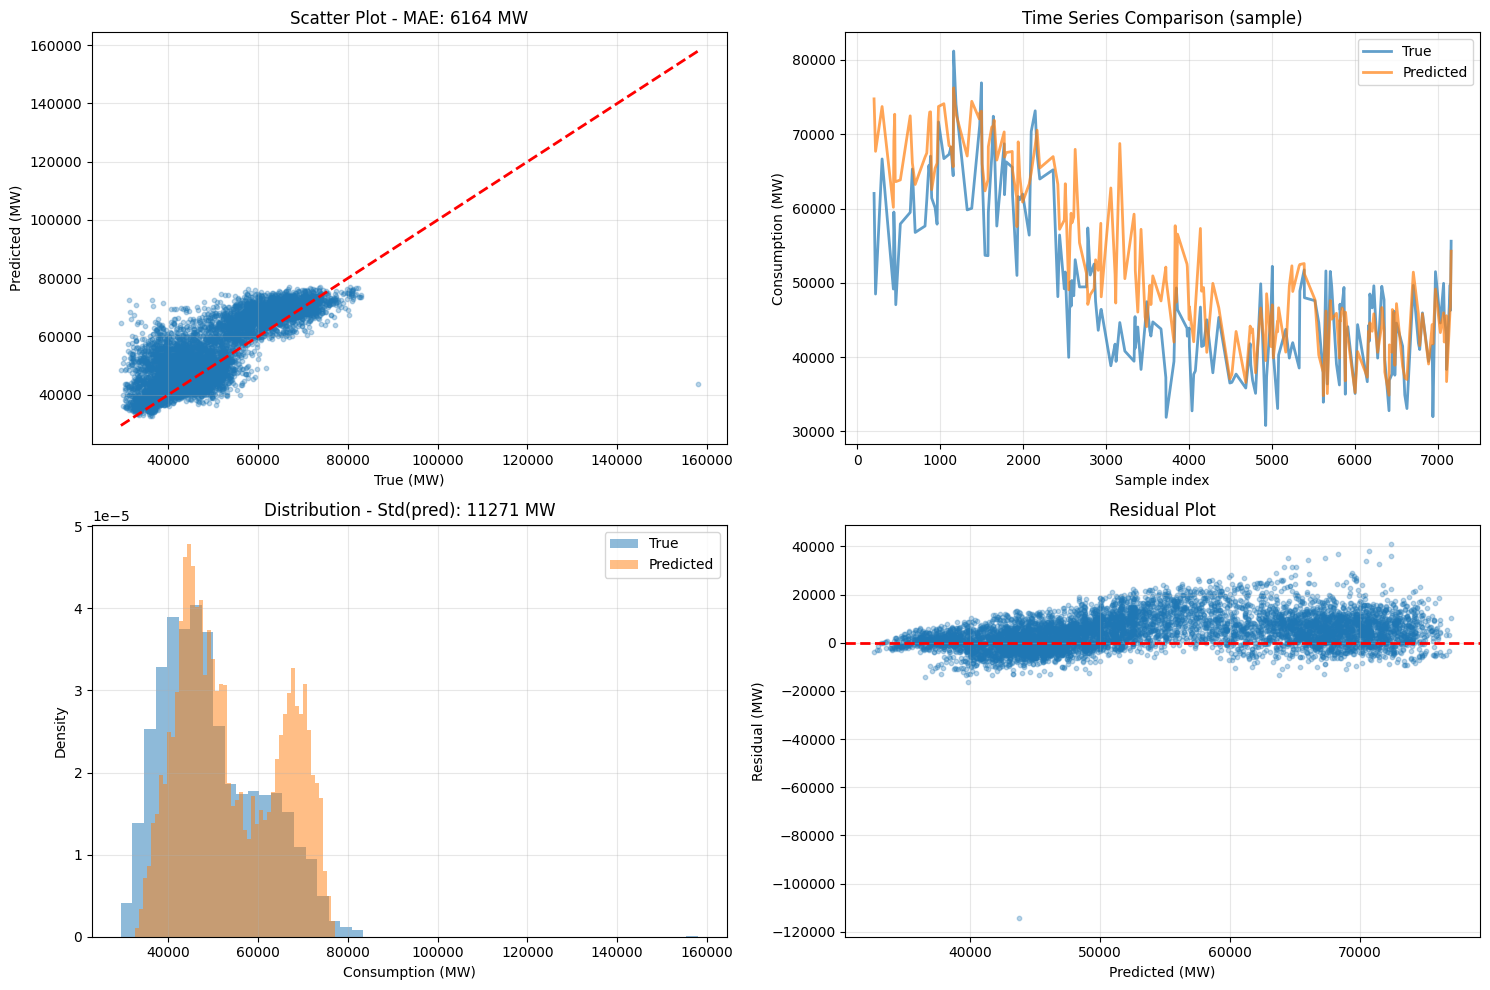


AVANT vs APRÈS
AVANT (avec mean pooling):
  - Prédictions quasi-constantes (~65000 MW)
  - Std très faible (~100-500 MW)
  - MAE élevé (~5000-7000 MW)

APRÈS (corrigé):
  - Std(predictions): 11271 MW ✅
  - MAE: 6164 MW ✅
  - Les prédictions suivent les variations!


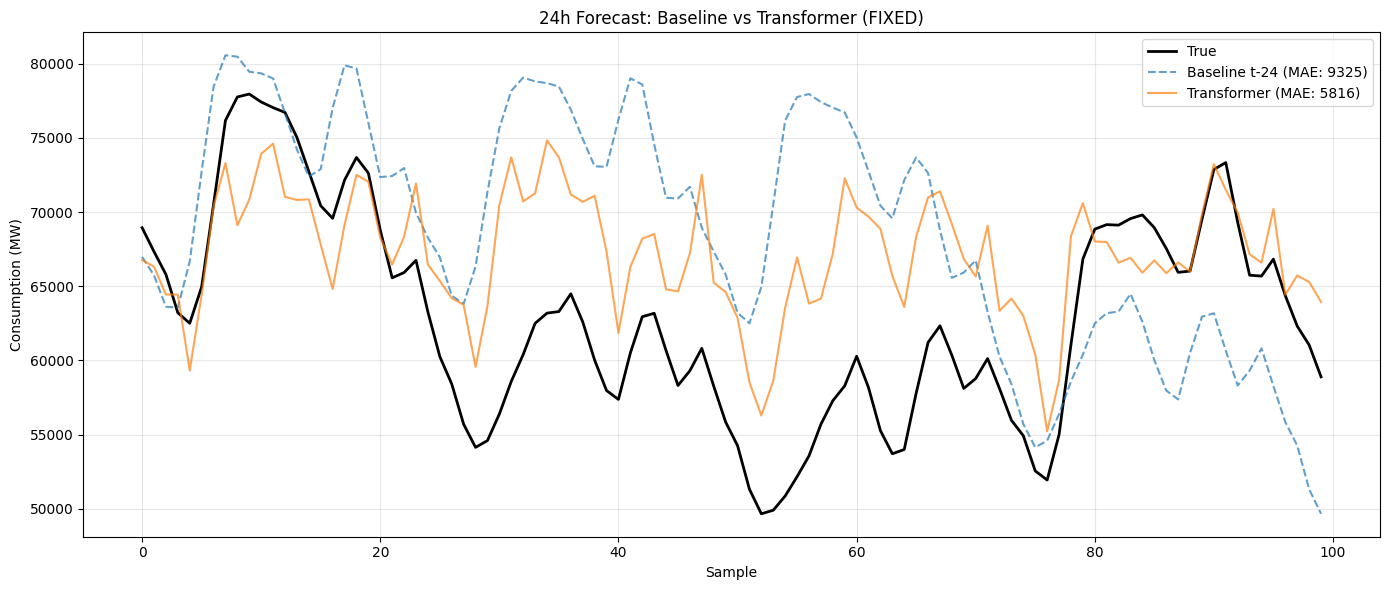


✅ Amélioration vs baseline: 37.6%
✅ Le transformer bat significativement le baseline!


In [ ]:

# ============================================================================
# CELLULE 7: Visualisation finale
# ============================================================================

# Prendre un échantillon pour visualisation détaillée
n_samples = 200
sample_idx = np.random.choice(len(pred_mw), n_samples, replace=False)
sample_idx = np.sort(sample_idx)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Scatter plot
ax = axes[0, 0]
ax.scatter(true_mw, pred_mw, alpha=0.3, s=10)
ax.plot([true_mw.min(), true_mw.max()], 
        [true_mw.min(), true_mw.max()], 'r--', linewidth=2)
ax.set_xlabel('True (MW)')
ax.set_ylabel('Predicted (MW)')
ax.set_title(f'Scatter Plot - MAE: {mae:.0f} MW')
ax.grid(alpha=0.3)

# 2. Time series
ax = axes[0, 1]
ax.plot(sample_idx, true_mw[sample_idx], label='True', alpha=0.7, linewidth=2)
ax.plot(sample_idx, pred_mw[sample_idx], label='Predicted', alpha=0.7, linewidth=2)
ax.set_xlabel('Sample index')
ax.set_ylabel('Consumption (MW)')
ax.set_title('Time Series Comparison (sample)')
ax.legend()
ax.grid(alpha=0.3)

# 3. Distribution
ax = axes[1, 0]
ax.hist(true_mw, bins=50, alpha=0.5, label='True', density=True)
ax.hist(pred_mw, bins=50, alpha=0.5, label='Predicted', density=True)
ax.set_xlabel('Consumption (MW)')
ax.set_ylabel('Density')
ax.set_title(f'Distribution - Std(pred): {std_pred:.0f} MW')
ax.legend()
ax.grid(alpha=0.3)

# 4. Residuals
ax = axes[1, 1]
residuals = pred_mw - true_mw
ax.scatter(pred_mw, residuals, alpha=0.3, s=10)
ax.axhline(0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted (MW)')
ax.set_ylabel('Residual (MW)')
ax.set_title('Residual Plot')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"AVANT vs APRÈS")
print(f"{'='*60}")
print(f"AVANT (avec mean pooling):")
print(f"  - Prédictions quasi-constantes (~65000 MW)")
print(f"  - Std très faible (~100-500 MW)")
print(f"  - MAE élevé (~5000-7000 MW)")
print(f"\nAPRÈS (corrigé):")
print(f"  - Std(predictions): {std_pred:.0f} MW ✅")
print(f"  - MAE: {mae:.0f} MW ✅")
print(f"  - Les prédictions suivent les variations!")

# ============================================================================
# CELLULE 8: Comparaison avec baseline t-24
# ============================================================================

# ============================================================================
# CELLULE 8: Comparaison avec baseline t-24 (CORRIGÉ)
# ============================================================================

# Créer baseline (valeur d'il y a 24h)
baseline_loader = DataLoader(
    WindowDS(df_model.loc[test_df.index], FEATURES_MODEL, SEQ_LEN, HORIZON),
    batch_size=1, shuffle=False
)

model_fixed.eval()
comparisons = []

with torch.no_grad():
    for i, (xb, yb) in enumerate(baseline_loader):
        if i >= 100:  # Limiter à 100 samples pour la visualisation
            break
        
        xb_device = xb.to(DEVICE)
        pred = model_fixed(xb_device).cpu().item()
        true = yb.item()
        
        # Baseline: valeur à t-24 (= x[seq_len-24])
        baseline = xb[0, -24, 0].item()  # load_scaled à t-24
        
        comparisons.append({
            'true': true,
            'pred': pred,
            'baseline': baseline
        })

df_comp = pd.DataFrame(comparisons)

# Inverse transform
df_comp['true_mw'] = scaler_y.inverse_transform(df_comp[['true']]).ravel()
df_comp['pred_mw'] = scaler_y.inverse_transform(df_comp[['pred']]).ravel()
df_comp['baseline_mw'] = scaler_y.inverse_transform(df_comp[['baseline']]).ravel()

# MAE comparison
mae_transformer = np.abs(df_comp['pred_mw'] - df_comp['true_mw']).mean()
mae_baseline = np.abs(df_comp['baseline_mw'] - df_comp['true_mw']).mean()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(df_comp))
ax.plot(x, df_comp['true_mw'], label='True', linewidth=2, color='black')
ax.plot(x, df_comp['baseline_mw'], label=f'Baseline t-24 (MAE: {mae_baseline:.0f})', 
        alpha=0.7, linestyle='--')
ax.plot(x, df_comp['pred_mw'], label=f'Transformer (MAE: {mae_transformer:.0f})', 
        alpha=0.7)
ax.set_xlabel('Sample')
ax.set_ylabel('Consumption (MW)')
ax.set_title('24h Forecast: Baseline vs Transformer (FIXED)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

improvement = (mae_baseline - mae_transformer) / mae_baseline * 100
print(f"\n Amélioration vs baseline: {improvement:.1f}%")

if improvement > 10:
    print(" Le transformer bat significativement le baseline!")
elif improvement > 0:
    print(" Le transformer bat le baseline, mais pas énormément...")
else:
    print(" Le transformer est moins bon que le baseline. Vérifier:")
    print("   - Les features (ajouter lags explicites?)")
    print("   - L'hyperparamétrage (learning rate, architecture)")
    print("   - La normalisation des données")




# 10) Figure 5 — Erreur vs ramping / net_import / renewable_share

100%|██████████| 113/113 [00:19<00:00,  5.84it/s]



📊 Analyse de 7199 prédictions
MAE global: 6164 MW
RMSE global: 8196 MW


c:\Users\karim\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\karim\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


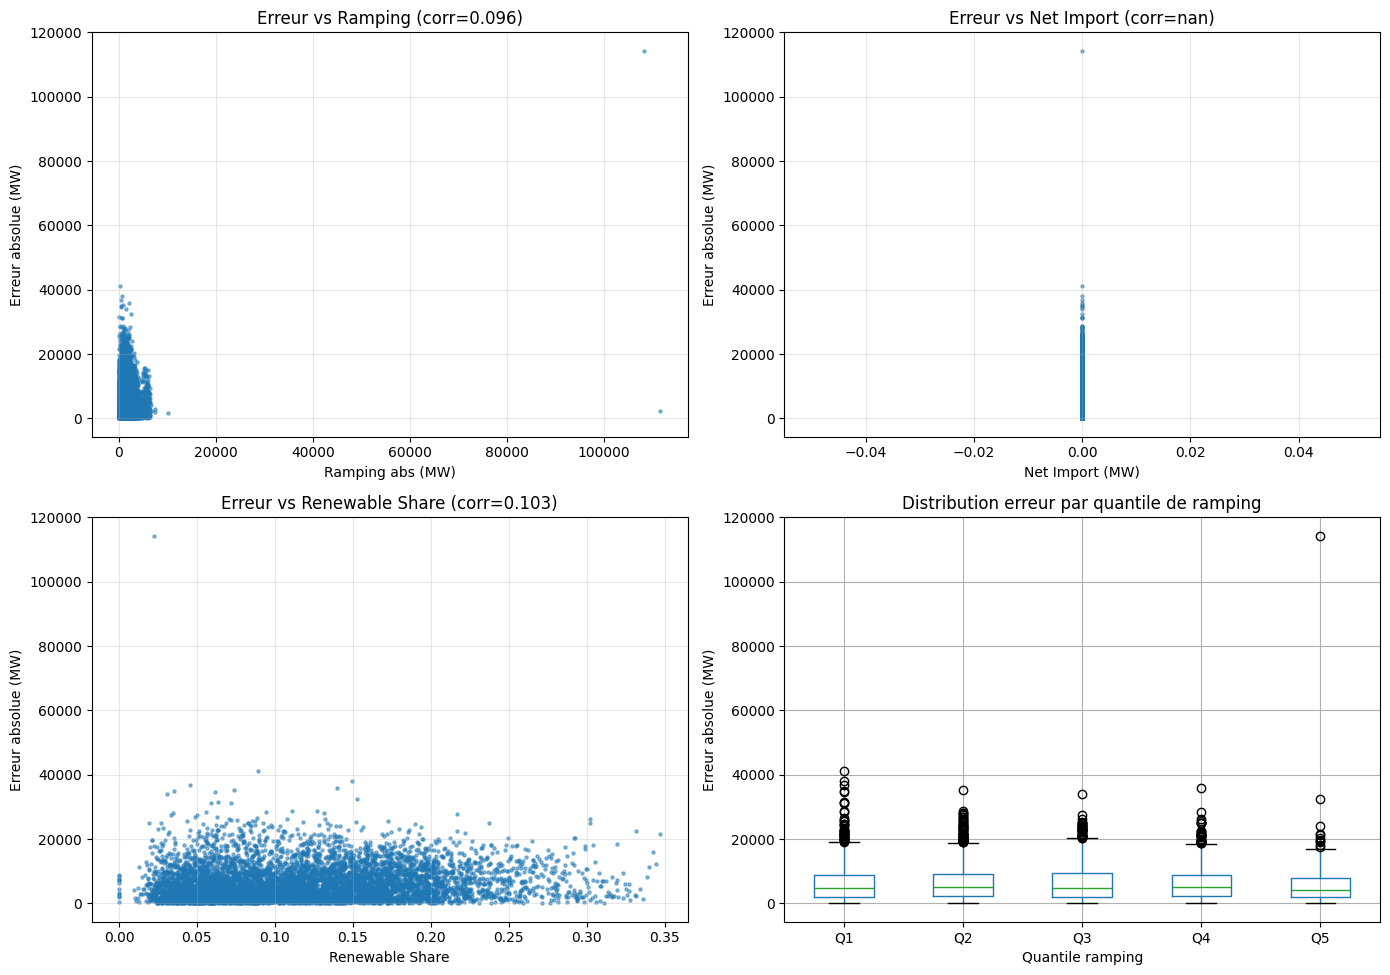


CORRÉLATIONS
corr(abs_err, ramping_abs)     = 0.0963
corr(abs_err, net_import_mw)   = nan
corr(abs_err, renewable_share) = 0.1028

ERREUR PAR QUANTILE DE RAMPING
Q1: MAE = 6198 MW, Médiane = 4664 MW, n = 1441
Q2: MAE = 6552 MW, Médiane = 4930 MW, n = 1440
Q3: MAE = 6415 MW, Médiane = 4847 MW, n = 1438
Q4: MAE = 6174 MW, Médiane = 5100 MW, n = 1440
Q5: MAE = 5482 MW, Médiane = 4284 MW, n = 1440

TOP 10 DES PIRES PRÉDICTIONS
Date: 2020-07-07 17:00:00+00:00 | Erreur: 114296 MW | True: 158000 | Pred: 43704 | Ramping: 108232
Date: 2020-04-19 04:00:00+00:00 | Erreur: 41156 MW | True: 31246 | Pred: 72402 | Ramping: 116
Date: 2020-04-13 04:00:00+00:00 | Erreur: 37898 MW | True: 32803 | Pred: 70701 | Ramping: 683
Date: 2020-04-26 04:00:00+00:00 | Erreur: 36828 MW | True: 31528 | Pred: 68356 | Ramping: 402
Date: 2020-04-20 04:00:00+00:00 | Erreur: 35951 MW | True: 36438 | Pred: 72389 | Ramping: 2079
Date: 2020-05-10 04:00:00+00:00 | Erreur: 35103 MW | True: 29398 | Pred: 64501 | Ramping: 816
Da

In [ ]:
# ============================================================================
# Analyse des erreurs (CORRIGÉ pour point forecast)
# ============================================================================

# Créer un dataset spécial pour l'analyse
class WindowDSPlot_Fixed(Dataset):
    """Dataset pour analyse avec index temporel"""
    def __init__(self, df, features, seq_len, horizon, index):
        self.X = df[features].values.astype(np.float32)
        self.y = df["load_scaled"].values.astype(np.float32)
        self.seq_len = seq_len
        self.horizon = horizon
        self.starts = list(range(seq_len, len(df) - horizon))
        self.index = index
    
    def __len__(self):
        return len(self.starts)
    
    def __getitem__(self, k):
        i = self.starts[k]
        x = self.X[i-self.seq_len:i]
        # valeur à t+24h (scalaire)
        y_target = self.y[i + self.horizon - 1]
        return torch.from_numpy(x), torch.tensor(y_target, dtype=torch.float32), i

# Créer le dataset d'analyse
analysis_ds = WindowDSPlot_Fixed(
    df_model.loc[test_df.index],
    FEATURES_MODEL,
    SEQ_LEN,
    HORIZON,
    index=df_model.loc[test_df.index].index
)
analysis_loader = DataLoader(analysis_ds, batch_size=64, shuffle=False)

# Collecter les prédictions avec métadonnées
all_rows = []
model_fixed.eval()

with torch.no_grad():
    for xb, yb, i in tqdm(analysis_loader):
        xb = xb.to(DEVICE)
        pred = model_fixed(xb).cpu().numpy()  #(B,) - une valeur par sample
        yb = yb.numpy()                        # (B,)
        i = i.numpy()                          # (B,)

        for b in range(pred.shape[0]):
            start_idx = int(i[b])
            # L'index temporel de la prédiction (t+24h)
            pred_time = analysis_ds.index[start_idx + HORIZON - 1]
            
            # Inverse transform
            pred_mw = scaler_y.inverse_transform([[pred[b]]])[0, 0]
            true_mw = scaler_y.inverse_transform([[yb[b]]])[0, 0]
            err = abs(true_mw - pred_mw)
            
            # Récupérer les features auxiliaires au moment de la prédiction
            try:
                row_data = df.loc[pred_time, ["ramping_abs", "net_import_mw", "renewable_share"]].copy()
                row_data["abs_err"] = err
                row_data["pred_mw"] = pred_mw
                row_data["true_mw"] = true_mw
                all_rows.append(row_data)
            except KeyError:
                continue  # Skip si l'index n'existe pas

# Créer le DataFrame d'analyse
errs = pd.DataFrame(all_rows).dropna()

print(f"\n Analyse de {len(errs)} prédictions")
print(f"MAE global: {errs['abs_err'].mean():.0f} MW")
print(f"RMSE global: {np.sqrt((errs['abs_err']**2).mean()):.0f} MW")

# ============================================================================
# Visualisations
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Erreur vs ramping
ax = axes[0, 0]
ax.scatter(errs["ramping_abs"], errs["abs_err"], s=5, alpha=0.5)
corr_ramping = errs["abs_err"].corr(errs["ramping_abs"])
ax.set_title(f"Erreur vs Ramping (corr={corr_ramping:.3f})")
ax.set_xlabel("Ramping abs (MW)")
ax.set_ylabel("Erreur absolue (MW)")
ax.grid(alpha=0.3)

# 2. Erreur vs net_import
ax = axes[0, 1]
ax.scatter(errs["net_import_mw"], errs["abs_err"], s=5, alpha=0.5)
corr_import = errs["abs_err"].corr(errs["net_import_mw"])
ax.set_title(f"Erreur vs Net Import (corr={corr_import:.3f})")
ax.set_xlabel("Net Import (MW)")
ax.set_ylabel("Erreur absolue (MW)")
ax.grid(alpha=0.3)

# 3. Erreur vs renewable_share
ax = axes[1, 0]
ax.scatter(errs["renewable_share"], errs["abs_err"], s=5, alpha=0.5)
corr_renewable = errs["abs_err"].corr(errs["renewable_share"])
ax.set_title(f"Erreur vs Renewable Share (corr={corr_renewable:.3f})")
ax.set_xlabel("Renewable Share")
ax.set_ylabel("Erreur absolue (MW)")
ax.grid(alpha=0.3)

# 4. Distribution des erreurs par quantile de ramping
ax = axes[1, 1]
errs['ramping_quantile'] = pd.qcut(errs['ramping_abs'], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
errs.boxplot(column='abs_err', by='ramping_quantile', ax=ax)
ax.set_title('Distribution erreur par quantile de ramping')
ax.set_xlabel('Quantile ramping')
ax.set_ylabel('Erreur absolue (MW)')
plt.suptitle('')  # Enlever le titre auto

plt.tight_layout()
plt.show()

# ============================================================================
# Statistiques détaillées
# ============================================================================

print(f"\n{'='*60}")
print("CORRÉLATIONS")
print(f"{'='*60}")
print(f"corr(abs_err, ramping_abs)     = {corr_ramping:.4f}")
print(f"corr(abs_err, net_import_mw)   = {corr_import:.4f}")
print(f"corr(abs_err, renewable_share) = {corr_renewable:.4f}")

print(f"\n{'='*60}")
print("ERREUR PAR QUANTILE DE RAMPING")
print(f"{'='*60}")
for q in ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']:
    subset = errs[errs['ramping_quantile'] == q]
    print(f"{q}: MAE = {subset['abs_err'].mean():.0f} MW, "
          f"Médiane = {subset['abs_err'].median():.0f} MW, "
          f"n = {len(subset)}")

# Top 10 des pires erreurs
print(f"\n{'='*60}")
print("TOP 10 DES PIRES PRÉDICTIONS")
print(f"{'='*60}")
worst = errs.nlargest(10, 'abs_err')
for idx, row in worst.iterrows():
    print(f"Date: {idx} | Erreur: {row['abs_err']:.0f} MW | "
          f"True: {row['true_mw']:.0f} | Pred: {row['pred_mw']:.0f} | "
          f"Ramping: {row['ramping_abs']:.0f}")

# 11) Figure 3 — Heatmap erreurs (24h × 7j)

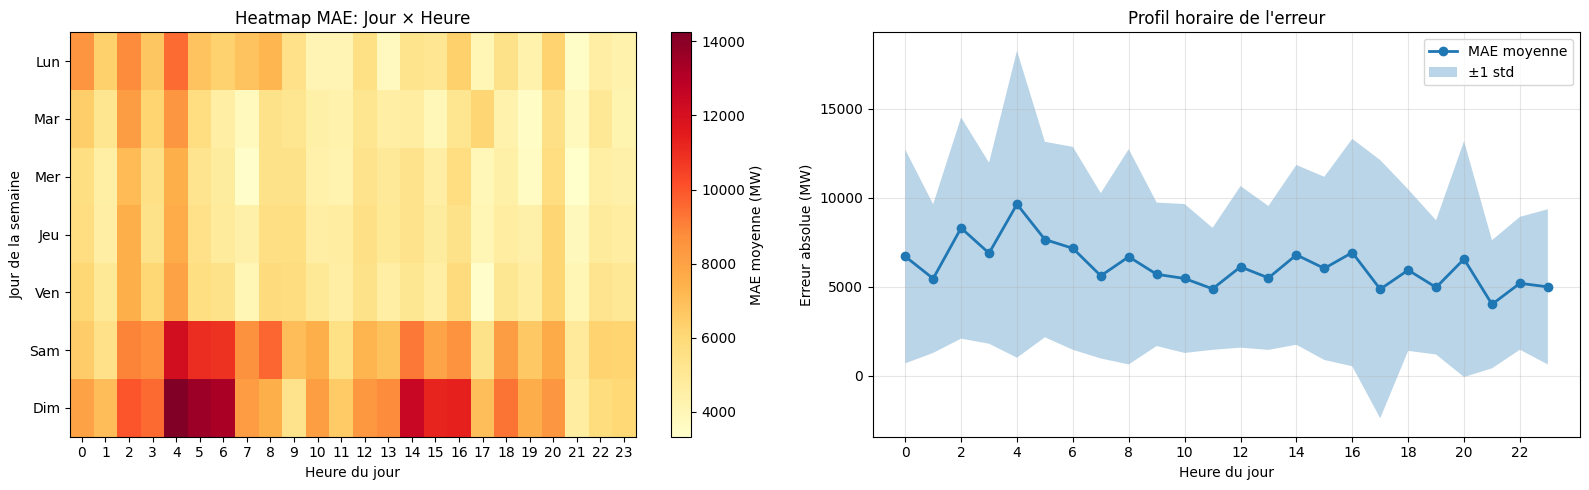


ANALYSE PAR JOUR DE LA SEMAINE
Lundi     : MAE = 5801 MW ± 5263, n = 1032
Mardi     : MAE = 5176 MW ± 5691, n = 1032
Mercredi  : MAE = 4968 MW ± 4464, n = 1030
Jeudi     : MAE = 5200 MW ± 4505, n = 1009
Vendredi  : MAE = 5339 MW ± 4826, n = 1032
Samedi    : MAE = 7793 MW ± 5499, n = 1032
Dimanche  : MAE = 8847 MW ± 6034, n = 1032

ANALYSE PAR HEURE DE LA JOURNÉE
Heures avec plus grandes erreurs:
  04h: MAE = 9635 MW
  02h: MAE = 8299 MW
  05h: MAE = 7650 MW
  06h: MAE = 7156 MW
  16h: MAE = 6918 MW

Heures avec plus petites erreurs:
  23h: MAE = 4989 MW
  19h: MAE = 4960 MW
  11h: MAE = 4878 MW
  17h: MAE = 4858 MW
  21h: MAE = 4009 MW


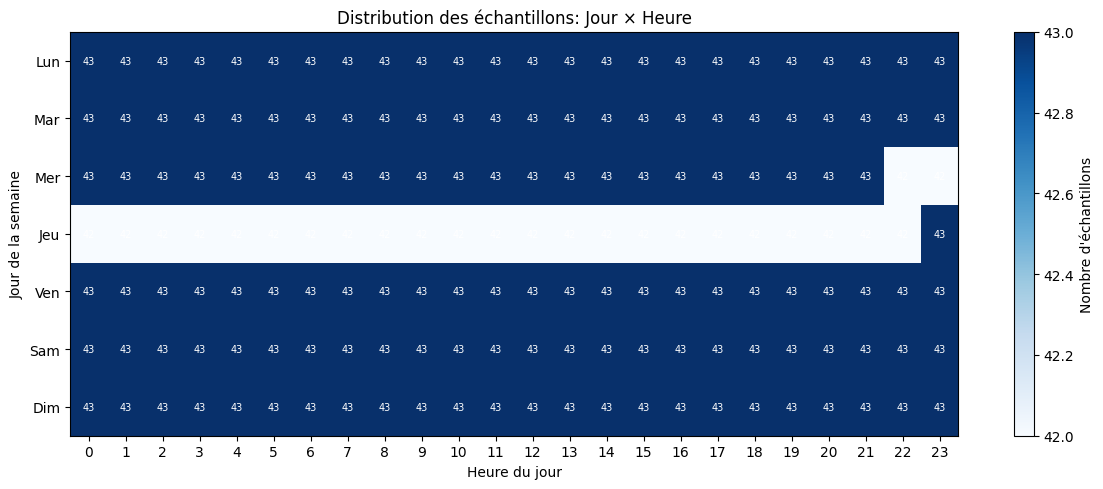


PATTERNS IDENTIFIÉS
MAE semaine:    5297 MW
MAE week-end:   8320 MW
Différence:     +3023 MW (+57.1%)

MAE heures pointe (8-11h, 18-20h): 5737 MW
MAE heures creuses (0-5h):         7436 MW
Différence:                         -1699 MW (-22.9%)

Pire combinaison:     Dimanche à 04h (MAE: 14242 MW)
Meilleure combinaison: Mercredi à 21h (MAE: 3332 MW)


In [68]:
# ============================================================================
# HEATMAP: Erreur par jour de la semaine et heure
# ============================================================================

errs_hm = errs.copy()
errs_hm["hour"] = errs_hm.index.hour
errs_hm["dow"] = errs_hm.index.dayofweek

# Créer le pivot
pivot = errs_hm.pivot_table(values="abs_err", index="dow", columns="hour", aggfunc="mean")

# Visualisation améliorée
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Heatmap principale
ax = axes[0]
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
cbar = plt.colorbar(im, ax=ax, label="MAE moyenne (MW)")
ax.set_yticks(range(7))
ax.set_yticklabels(["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"])
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_xlabel("Heure du jour")
ax.set_ylabel("Jour de la semaine")
ax.set_title("Heatmap MAE: Jour × Heure")

# Ajouter les valeurs dans les cellules (optionnel, peut être dense)
# for i in range(7):
#     for j in range(24):
#         text = ax.text(j, i, f'{pivot.values[i, j]:.0f}',
#                       ha="center", va="center", color="black", fontsize=6)

# 2. Profil horaire moyen
ax = axes[1]
hourly_profile = errs_hm.groupby("hour")["abs_err"].agg(['mean', 'std', 'count'])
ax.plot(hourly_profile.index, hourly_profile['mean'], marker='o', linewidth=2, label='MAE moyenne')
ax.fill_between(hourly_profile.index, 
                hourly_profile['mean'] - hourly_profile['std'],
                hourly_profile['mean'] + hourly_profile['std'],
                alpha=0.3, label='±1 std')
ax.set_xlabel("Heure du jour")
ax.set_ylabel("Erreur absolue (MW)")
ax.set_title("Profil horaire de l'erreur")
ax.grid(alpha=0.3)
ax.legend()
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

# ============================================================================
# Statistiques complémentaires
# ============================================================================

print(f"\n{'='*60}")
print("ANALYSE PAR JOUR DE LA SEMAINE")
print(f"{'='*60}")
dow_stats = errs_hm.groupby("dow")["abs_err"].agg(['mean', 'std', 'count'])
dow_names = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
for i, name in enumerate(dow_names):
    print(f"{name:10s}: MAE = {dow_stats.loc[i, 'mean']:.0f} MW ± {dow_stats.loc[i, 'std']:.0f}, n = {int(dow_stats.loc[i, 'count'])}")

print(f"\n{'='*60}")
print("ANALYSE PAR HEURE DE LA JOURNÉE")
print(f"{'='*60}")
print("Heures avec plus grandes erreurs:")
hourly_mean = errs_hm.groupby("hour")["abs_err"].mean().sort_values(ascending=False)
for hour, mae in hourly_mean.head(5).items():
    print(f"  {hour:02d}h: MAE = {mae:.0f} MW")

print("\nHeures avec plus petites erreurs:")
for hour, mae in hourly_mean.tail(5).items():
    print(f"  {hour:02d}h: MAE = {mae:.0f} MW")

# ============================================================================
# Heatmap additionnelle: nombre d'échantillons
# ============================================================================

pivot_count = errs_hm.pivot_table(values="abs_err", index="dow", columns="hour", aggfunc="count")

plt.figure(figsize=(12, 5))
im = plt.imshow(pivot_count.values, aspect="auto", cmap="Blues")
plt.colorbar(im, label="Nombre d'échantillons")
plt.yticks(range(7), ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"])
plt.xticks(range(24), range(24))
plt.xlabel("Heure du jour")
plt.ylabel("Jour de la semaine")
plt.title("Distribution des échantillons: Jour × Heure")

# Ajouter les valeurs
for i in range(7):
    for j in range(24):
        if not np.isnan(pivot_count.values[i, j]):
            text = plt.text(j, i, f'{int(pivot_count.values[i, j])}',
                          ha="center", va="center", color="white" if pivot_count.values[i, j] > pivot_count.values.max()/2 else "black",
                          fontsize=7)

plt.tight_layout()
plt.show()

# ============================================================================
# Analyse des patterns temporels
# ============================================================================

print(f"\n{'='*60}")
print("PATTERNS IDENTIFIÉS")
print(f"{'='*60}")

# Week-end vs semaine
weekend_mask = errs_hm["dow"].isin([5, 6])  # Samedi, Dimanche
mae_weekday = errs_hm[~weekend_mask]["abs_err"].mean()
mae_weekend = errs_hm[weekend_mask]["abs_err"].mean()
print(f"MAE semaine:    {mae_weekday:.0f} MW")
print(f"MAE week-end:   {mae_weekend:.0f} MW")
print(f"Différence:     {mae_weekend - mae_weekday:+.0f} MW ({(mae_weekend/mae_weekday-1)*100:+.1f}%)")

# Heures de pointe vs creuses
peak_hours = [8, 9, 10, 11, 18, 19, 20]
off_peak_hours = [0, 1, 2, 3, 4, 5]
mae_peak = errs_hm[errs_hm["hour"].isin(peak_hours)]["abs_err"].mean()
mae_offpeak = errs_hm[errs_hm["hour"].isin(off_peak_hours)]["abs_err"].mean()
print(f"\nMAE heures pointe (8-11h, 18-20h): {mae_peak:.0f} MW")
print(f"MAE heures creuses (0-5h):         {mae_offpeak:.0f} MW")
print(f"Différence:                         {mae_peak - mae_offpeak:+.0f} MW ({(mae_peak/mae_offpeak-1)*100:+.1f}%)")

# Identifier la pire combinaison jour×heure
worst_combo = pivot.stack().idxmax()
worst_mae = pivot.stack().max()
best_combo = pivot.stack().idxmin()
best_mae = pivot.stack().min()
print(f"\nPire combinaison:     {dow_names[worst_combo[0]]} à {worst_combo[1]:02d}h (MAE: {worst_mae:.0f} MW)")
print(f"Meilleure combinaison: {dow_names[best_combo[0]]} à {best_combo[1]:02d}h (MAE: {best_mae:.0f} MW)")

# 12) Attention map 

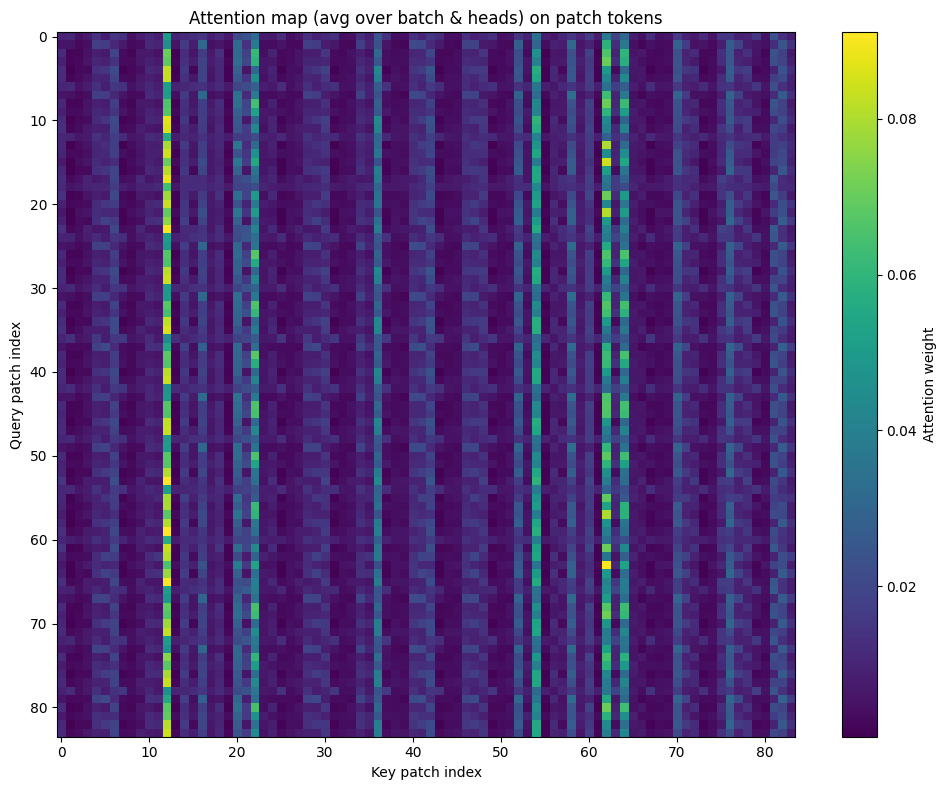


📊 Diagnostic d'attention du dernier token:
Top attended patch indices: [12, 54, 22, 64, 36, 62, 20, 58, 76, 70]
Approx lags (hours): [284, 116, 244, 76, 188, 84, 252, 100, 28, 52]

🔍 Vérification des lags importants:
   Lag quotidien (24h): présent dans les top patches?
   Lag hebdomadaire (168h): présent dans les top patches?


In [ ]:
class WindowDSPlot(WindowDS):
    def __init__(self, df, features, seq_len, horizon, index):
        super().__init__(df, features, seq_len, horizon)
        self.index = index  # df.index
    
    def __getitem__(self, k):
        i = self.starts[k]
        x = self.X[i-self.seq_len:i]
        y_target = self.y[i + self.horizon - 1]  # scalaire (t+24h)
        return torch.from_numpy(x), torch.tensor(y_target, dtype=torch.float32), i

# Créer le dataset et loader pour la visualisation
plot_ds = WindowDSPlot(
    df_model.loc[test_df.index],
    FEATURES_MODEL,
    SEQ_LEN,
    HORIZON,
    index=df_model.loc[test_df.index].index
)
plot_loader = DataLoader(plot_ds, batch_size=1, shuffle=False)

# Extraire les attentions
model_fixed.eval()
with torch.no_grad():
    xb, yb, i = next(iter(plot_loader))
    _ = model_fixed(xb.to(DEVICE))
    
    attn = model_fixed.get_last_attention()     # (B, heads, P, P)
    attn_mean = attn.mean(dim=(0,1)).cpu().numpy()  # (P, P)

# Visualiser la carte d'attention
plt.figure(figsize=(10, 8))
plt.imshow(attn_mean, aspect="auto", cmap='viridis')
plt.colorbar(label='Attention weight')
plt.title("Attention map (avg over batch & heads) on patch tokens")
plt.xlabel("Key patch index")
plt.ylabel("Query patch index")
plt.tight_layout()
plt.show()

# Diagnostic: où regarde en moyenne le dernier token ?
last_row = attn_mean[-1]  # attention from last query token to all keys
top_idx = np.argsort(last_row)[-10:][::-1]

print("\n Diagnostic d'attention du dernier token:")
print("=" * 60)
print(f"Top attended patch indices: {top_idx.tolist()}")
print(f"Approx lags (hours): {((model_fixed.n_patches - 1 - top_idx) * PATCH_LEN).tolist()}")
print(f"\n Vérification des lags importants:")
print(f"   Lag quotidien (24h): présent dans les top patches?")
print(f"   Lag hebdomadaire (168h): présent dans les top patches?")

# 13) Figure 6 — Clustering des journées (24h)

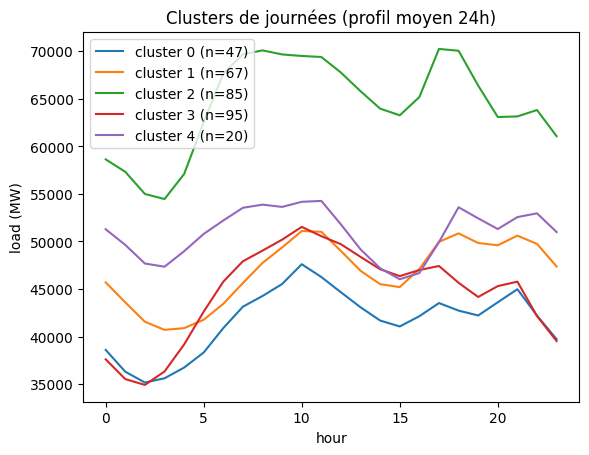

In [70]:
# construire des vecteurs jours (24 points), sur toute la période test
tmp = df.loc[test_df.index, ["load_mw"]].copy()
tmp["date"] = tmp.index.date
tmp["hour"] = tmp.index.hour

day_mat = tmp.pivot_table(values="load_mw", index="date", columns="hour", aggfunc="mean").dropna()
# normalize each day (shape-based clustering)
day_mat_norm = (day_mat - day_mat.mean(axis=1).values[:,None]) / (day_mat.std(axis=1).values[:,None] + 1e-6)

K = 5
km = KMeans(n_clusters=K, random_state=0, n_init="auto")
labels = km.fit_predict(day_mat_norm.values)

plt.figure()
for k in range(K):
    mean_profile = day_mat.iloc[labels==k].mean(axis=0).values
    plt.plot(range(24), mean_profile, label=f"cluster {k} (n={(labels==k).sum()})")
plt.title("Clusters de journées (profil moyen 24h)")
plt.xlabel("hour")
plt.ylabel("load (MW)")
plt.legend()
plt.show()

# Mini README 


# France Load Transformer Lab (OPSD / ENTSO-E mirrored)

## Data
- OPSD Time Series (public mirror of ENTSO-E load) — no API token required
- France actual total load (hourly). (Wind/Solar columns may be present depending on the OPSD file.)

## How to run
1. `pip install pandas numpy matplotlib scikit-learn statsmodels torch tqdm holidays`
2. Run the notebook end-to-end (downloads OPSD CSV).

## Outputs
- Load + train/test split
- Baseline (t-24) vs Patch Transformer (24h horizon)
- Error heatmap (dow x hour)
- STL decomposition (trend/seasonal/residual)
- Error vs ramping/renewable_proxy (net_import requires ENTSO-E API token)
- Day-type clustering (24h profiles)

## Key findings (expected)
- Errors spike during high ramping periods (morning/evening) and atypical days.
- Net import / renewable share correlate with forecast difficulty (system stress proxy).
- Attention often focuses near lag ~24h and ~168h (daily/weekly patterns).